라이브러리 설치

In [1]:
! pip install opencv-python pixellib 

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 36.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 MB 38.2 MB/s eta 0:00:0000:0100:01
  DEPRECATION: Building 'fvcore' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` opt

라이브러리 불러오기

In [26]:
import cv2
import os
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

이미지 불러오기

이미지 크기: (505, 396, 3)


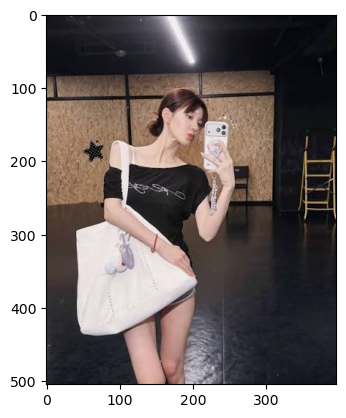

In [28]:
home_dir = os.getenv('HOME')
img_path = os.path.join(home_dir, "work/human_segmentation/images/human.jpg")
img_orig = cv2.imread(img_path)

print(f"이미지 크기: {img_orig.shape}")

plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB))
plt.show()

DeepLapv3 불러오기

In [29]:
model = deeplabv3_resnet101(pretrained=True).eval()

이미지 전처리

In [30]:
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)), 
    T.ToTensor(),
])

In [31]:
input_tensor = transform(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)).unsqueeze(0)

세크멘테이션 수행

In [32]:
with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

output_predictions_resized = cv2.resize(output_predictions, (img_orig.shape[1], img_orig.shape[0]), interpolation=cv2.INTER_NEAREST)

Pascal 데이터의 라벨종류

In [34]:
LABEL_NAMES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tv'
]
len(LABEL_NAMES)

21

Segmentation 결과 확인

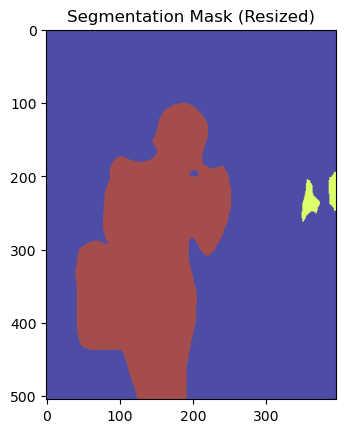

In [35]:
plt.imshow(output_predictions_resized, cmap="jet", alpha=0.7)
plt.title("Segmentation Mask (Resized)")
plt.show()

어떤 클래스가 있는지 확인

In [36]:
unique_classes = np.unique(output_predictions_resized)
unique_classes

array([ 0,  9, 15], dtype=uint8)

In [37]:
for class_id in unique_classes:
    print(LABEL_NAMES[class_id])

background
chair
person


컬러맵 생성

In [38]:
colormap = np.zeros((256, 3), dtype=int)
ind = np.arange(256, dtype=int)

for shift in reversed(range(8)):
    for channel in range(3):
        colormap[:, channel] |= ((ind >> channel) & 1) << shift
    ind >>= 3

colormap[:20]

array([[  0,   0,   0],
       [128,   0,   0],
       [  0, 128,   0],
       [128, 128,   0],
       [  0,   0, 128],
       [128,   0, 128],
       [  0, 128, 128],
       [128, 128, 128],
       [ 64,   0,   0],
       [192,   0,   0],
       [ 64, 128,   0],
       [192, 128,   0],
       [ 64,   0, 128],
       [192,   0, 128],
       [ 64, 128, 128],
       [192, 128, 128],
       [  0,  64,   0],
       [128,  64,   0],
       [  0, 192,   0],
       [128, 192,   0]])

사람 클래스 색상

In [39]:
colormap[15]

array([192, 128, 128])

사람 마스크 생성
클래스 ID 15 (사람)

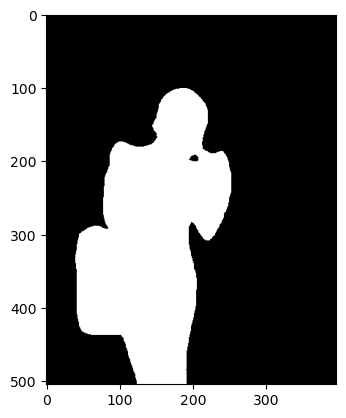

In [47]:
seg_map = (output_predictions_resized == 15)
img_mask = seg_map.astype(np.uint8) * 255  
color_mask = cv2.applyColorMap(img_mask, cv2.COLORMAP_JET)

plt.imshow(img_mask, cmap='gray')  
plt.show()

원본과 마스크 합성

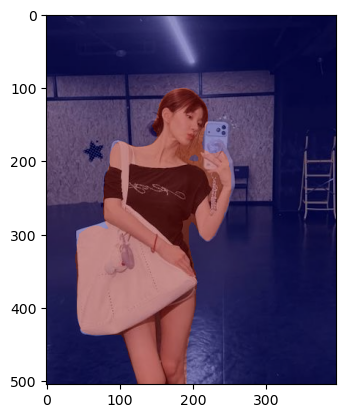

In [41]:
img_show = cv2.addWeighted(img_orig, 0.6, color_mask, 0.4, 0.0)

plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

원본 이미지 블러

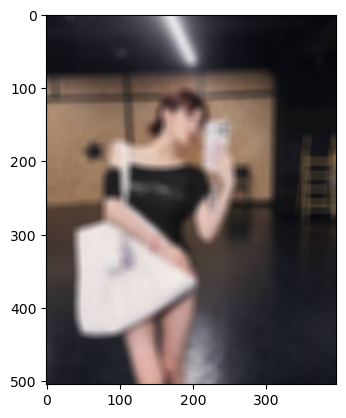

In [42]:
img_orig_blur = cv2.blur(img_orig, (13, 13))

plt.imshow(cv2.cvtColor(img_orig_blur, cv2.COLOR_BGR2RGB))
plt.show()

사람 마스크를 BGR로 변환

In [43]:
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)

배경 마스크 생성

In [44]:
img_bg_mask = cv2.bitwise_not(img_mask_color)

흐린 배경 추출

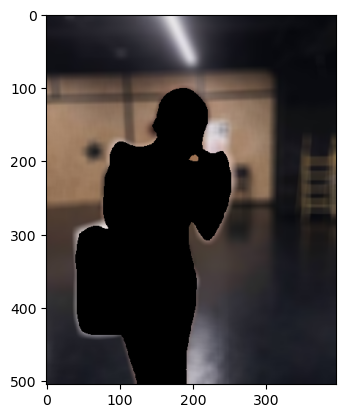

In [45]:
img_bg_blur = cv2.bitwise_and(img_orig_blur, img_bg_mask)
plt.imshow(cv2.cvtColor(img_bg_blur, cv2.COLOR_BGR2RGB))
plt.show()

최종 아웃포커싱

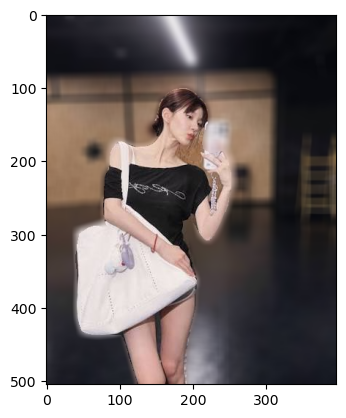

In [46]:
img_concat = np.where(img_mask_color==255, img_orig, img_bg_blur)

plt.imshow(cv2.cvtColor(img_concat, cv2.COLOR_BGR2RGB))
plt.show()

인물모드 사진에서 나타난 문제점
- 인물의 전체적인 영역은 비교적 잘 분리했지만, 손과 휴대폰처럼 경계가 복잡한 부분에서는 마스크가 정확하게 생성되지 않았음.
- 클래스를 확인할 때 배경에 있는 사물을 사다리가 아닌 chair로 인식함.

<img src="human_segmentation/images/problem.jpg" width="900">

+ images폴더에 추가로 제작한 사진을 추가하여 문제가 되는 부분을 표시함.

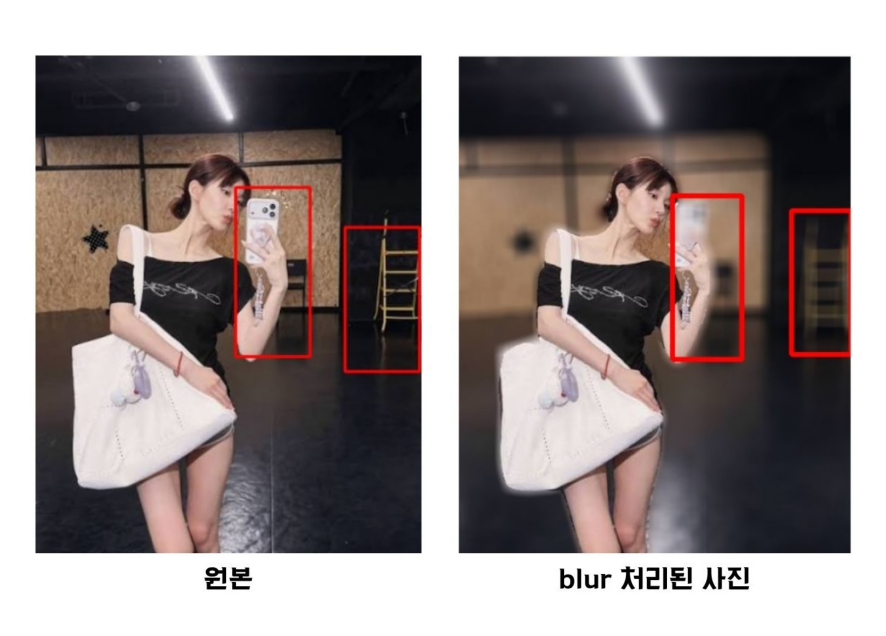

In [59]:
home_dir = os.getenv("HOME")

img = cv2.imread(home_dir + "/work/human_segmentation/images/problem.jpg")

plt.figure(figsize=(12,8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

Solution 제시
사물을 배경처리하고 인물과 배경으로 더 명확히 구분하고 다른 사물을 정확히 인식하게 하기위해서는 이러한 solution이 있다.
1. 이미지의 해상도를 높임
-> 이미지의 해상도가 높을수록 손, 휴대폰과 같은 작은 객체의 특징이 더 잘 보존된다. 따라서 모델이 객체의 경계를 더 정확하게 구분할 가능성이 높아진다.
2. DeepLabv3보다 더 정확한 Segmentation 모델 사용
-> DeepLabV3는 인물의 전체적인 영역은 잘 분리하지만, 손이나 휴대폰처럼 경계가 복잡한 부분에서는 정확도가 떨어질 수 있다. 따라서 Mask R-CNN과 같은 더 정밀한 세그멘테이션 모델을 사용하면 객체의 경계를 더욱 정확하게 분리할 수 있다.
3. 마스크 후처리
-> 모델이 생성한 마스크에는 작은 구멍이나 잡음이 포함될 수 있다.따라서 후처리를 적용하면 작은 오류를 제거하고 경계를 부드럽게 만들어 더 자연스러운 분할 결과를 얻을 수 있다.